In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/tweets.csv", encoding='latin-1')

print("Dataset Loaded Successfully ✅")
print("Shape of dataset:", df.shape)

Dataset Loaded Successfully ✅
Shape of dataset: (100, 3)


In [27]:
df.head()

,tweets,posted_by,label
0,The only reason the iPhone stands out is its s...,TheKanojia,neutral
1,"Its all a matter of choice, there are things ...",BloodytoothG,neutral
2,doing iPhone vs Android sigh,Dele_Tuyi,neutral
3,We should now introduce app multitasking on ou...,NserekoColline,positive
4,Android gives way more flexibility and options.,TechHelpIndia,positive


## Preprocessing

In [29]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweets     100 non-null    object
 1   posted_by  100 non-null    object
 2   label      100 non-null    object
dtypes: object(3)
memory usage: 2.5+ KB


tweets       0
posted_by    0
label        0
dtype: int64

In [31]:
df = df[['tweets', 'label']]

# Rename label → sentiment
df.rename(columns={'label': 'sentiment'}, inplace=True)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("After cleaning:")
print(df.shape)

df.head()

After cleaning:
(100, 2)


,tweets,sentiment
0,The only reason the iPhone stands out is its s...,neutral
1,"Its all a matter of choice, there are things ...",neutral
2,doing iPhone vs Android sigh,neutral
3,We should now introduce app multitasking on ou...,positive
4,Android gives way more flexibility and options.,positive


In [33]:
#Removing duplicate tweets
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print("After removing duplicates:")
print(df.shape)

After removing duplicates:
(98, 2)


In [35]:
df['length'] = df['tweets'].apply(len)

df.head()

,tweets,sentiment,length
0,The only reason the iPhone stands out is its s...,neutral,197
1,"Its all a matter of choice, there are things ...",neutral,126
2,doing iPhone vs Android sigh,neutral,28
3,We should now introduce app multitasking on ou...,positive,86
4,Android gives way more flexibility and options.,positive,47


## VISUALIZATION 1: TEXT LENGTH

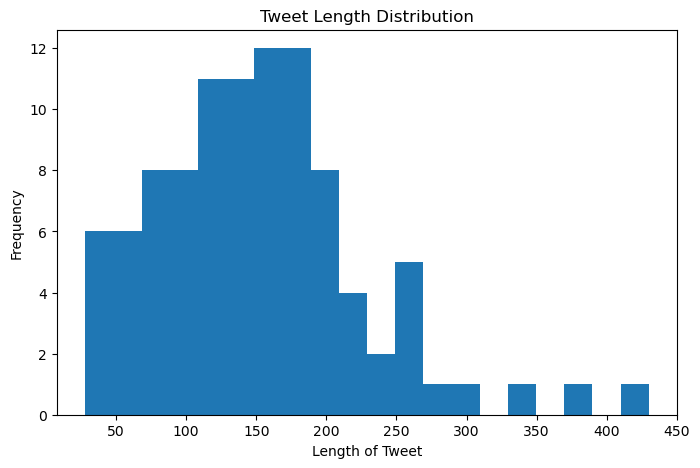

In [39]:
plt.figure(figsize=(8,5))
plt.hist(df['length'], bins=20)

plt.title("Tweet Length Distribution")
plt.xlabel("Length of Tweet")
plt.ylabel("Frequency")

plt.savefig("../visuals/01_tweet_length_distribution.png")

plt.show()

## VISUALIZATION 2: SENTIMENT DISTRIBUTION

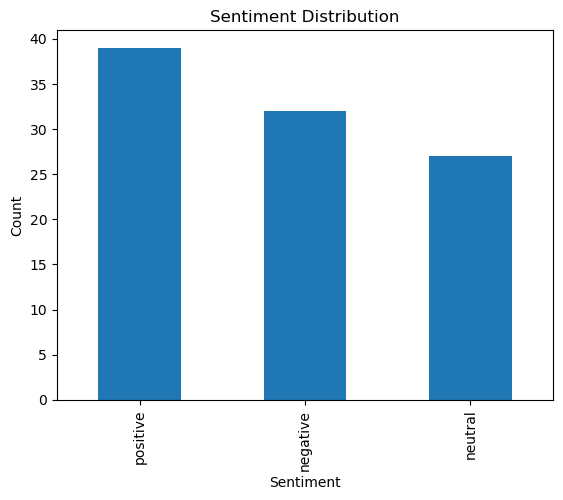

In [49]:
df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.savefig("../visuals/02_sentiment_distribution.png")

plt.show()

## Saving Cleaned Dataset

In [47]:
df[['tweets', 'sentiment']].to_csv("../data/labeled_tweets.csv", index=False)

print("Final cleaned dataset saved as labeled_tweets.csv ✅")

Final cleaned dataset saved as labeled_tweets.csv ✅
